# Adapted Dynamic Model Fusion for Credit Rating

Notebook nay ap dung **Dynamic Model Fusion / Dynamic Classifier Selection (DMF/DCS)** tu paper cho bai toan xep hang tin dung doanh nghiep.

Anh xa phuong phap:
- Paper: `CNN` hoc dac trung cuc bo, `GCNN` hoc quan he do thi tren MRI.
- Bai toan nay: `LSTM` hoc chuoi tai chinh/thoi gian, `GAT` hoc quan he do thi doanh nghiep.
- Phan duoc tai su dung truc tiep la **decision-level DCS**: neu hai mo hinh dong thuan thi lay nhan chung; neu bat dong thi chon mo hinh co diem tin cay dong cao hon dua tren validation competence va confidence cua mau test.

Luu y viet luan van: day la **DMF/DCS adapted to LSTM-GAT credit rating**, khong phai tai hien nguyen kien truc MRI CNN-GCNN cua paper.

Input bat buoc:
- `/kaggle/input/datasets/tailength/dmf-artifacts/dmf_gat_lstm/lstm_val_predictions.csv`
- `/kaggle/input/datasets/tailength/dmf-artifacts/dmf_gat_lstm/lstm_test_predictions.csv`
- `/kaggle/input/datasets/tailength/dmf-artifacts/dmf_gat_lstm/gat_val_predictions.csv`
- `/kaggle/input/datasets/tailength/dmf-artifacts/dmf_gat_lstm/gat_test_predictions.csv`


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report,
)
from sklearn.preprocessing import label_binarize

SEED = 42
np.random.seed(SEED)


def detect_kaggle_runtime() -> bool:
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '').strip():
        return True
    return Path('/kaggle/input').exists() and Path('/kaggle/working').exists()


IN_KAGGLE = detect_kaggle_runtime()


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'src').exists():
            return p
    return start


PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / 'credit_rating_artifacts'
KAGGLE_DMF_INPUT_ARTIFACT_DIR = Path('/kaggle/input/datasets/tailength/dmf-artifacts/dmf_gat_lstm')
DMF_ARTIFACT_DIR = ARTIFACT_DIR / 'dmf_gat_lstm'
DMF_INPUT_ARTIFACT_DIR = KAGGLE_DMF_INPUT_ARTIFACT_DIR if IN_KAGGLE and KAGGLE_DMF_INPUT_ARTIFACT_DIR.exists() else DMF_ARTIFACT_DIR
DMF_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('DMF input artifact dir:', DMF_INPUT_ARTIFACT_DIR)
print('DMF output artifact dir:', DMF_ARTIFACT_DIR)


Project root: /kaggle/working
DMF input artifact dir: /kaggle/input/datasets/tailength/dmf-artifacts/dmf_gat_lstm
DMF output artifact dir: /kaggle/working/credit_rating_artifacts/dmf_gat_lstm


In [2]:
LSTM_VAL_PATH = DMF_INPUT_ARTIFACT_DIR / 'lstm_val_predictions.csv'
LSTM_TEST_PATH = DMF_INPUT_ARTIFACT_DIR / 'lstm_test_predictions.csv'
GAT_VAL_PATH = DMF_INPUT_ARTIFACT_DIR / 'gat_val_predictions.csv'
GAT_TEST_PATH = DMF_INPUT_ARTIFACT_DIR / 'gat_test_predictions.csv'
LABEL_MAP_PATH = DMF_INPUT_ARTIFACT_DIR / 'label_mapping.csv'

required_paths = [LSTM_VAL_PATH, LSTM_TEST_PATH, GAT_VAL_PATH, GAT_TEST_PATH, LABEL_MAP_PATH]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError('Thieu DMF input artifact. Hay chay notebook LSTM va GAT truoc: ' + '; '.join(missing))

lstm_val_raw = pd.read_csv(LSTM_VAL_PATH)
lstm_test_raw = pd.read_csv(LSTM_TEST_PATH)
gat_val_raw = pd.read_csv(GAT_VAL_PATH)
gat_test_raw = pd.read_csv(GAT_TEST_PATH)
label_map = pd.read_csv(LABEL_MAP_PATH)

print('LSTM val/test:', lstm_val_raw.shape, lstm_test_raw.shape)
print('GAT  val/test:', gat_val_raw.shape, gat_test_raw.shape)
display(label_map)


LSTM val/test: (862, 12) (1723, 12)
GAT  val/test: (862, 13) (1723, 13)


,label_id,label_name
0,0,0
1,1,1
2,2,2


In [3]:
def prob_columns(frame):
    cols = [c for c in frame.columns if c.startswith('prob_')]
    return sorted(cols, key=lambda x: int(x.split('_')[1]))


def validate_prediction_frame(frame, model_key, split_name):
    probs = prob_columns(frame)
    if not probs:
        raise ValueError(f'{model_key} {split_name} prediction file has no prob_* columns')
    required = {'row_id', 'true_label', 'pred_label', *probs}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f'{model_key} {split_name} prediction file missing columns: {sorted(missing)}')
    duplicated = frame.loc[frame['row_id'].duplicated(), 'row_id'].head().tolist()
    if duplicated:
        raise ValueError(f'{model_key} {split_name} has duplicate row_id values: {duplicated}')
    return probs


def standardize_predictions(frame, model_key, split_name):
    frame = frame.copy()
    probs = validate_prediction_frame(frame, model_key, split_name)
    keep_meta = [c for c in ['row_id', 'split', 'ticker', 'company_name', 'rating_date', 'true_label', 'true_label_name'] if c in frame.columns]
    out = frame[keep_meta].copy()
    out[f'{model_key}_pred_label'] = frame['pred_label'].astype(int)
    out[f'{model_key}_confidence'] = frame['confidence'].astype(float) if 'confidence' in frame.columns else frame[probs].max(axis=1).astype(float)
    for c in probs:
        out[f'{model_key}_{c}'] = frame[c].astype(float)
    return out, probs


def align_pair(lstm_frame, gat_frame, split_name):
    lstm, lstm_probs = standardize_predictions(lstm_frame, 'lstm', split_name)
    gat, gat_probs = standardize_predictions(gat_frame, 'gat', split_name)
    if lstm_probs != gat_probs:
        raise ValueError(f'Probability columns mismatch on {split_name}: lstm={lstm_probs}, gat={gat_probs}')

    merged = lstm.merge(gat, on='row_id', suffixes=('_lstm_meta', '_gat_meta'), how='inner')
    if len(merged) != len(lstm) or len(merged) != len(gat):
        raise ValueError(
            f'Row_id mismatch on {split_name}: merged={len(merged)}, lstm={len(lstm)}, gat={len(gat)}. '
            'Kiem tra hai notebook co dung cung split va row_id khong.'
        )
    if not (merged['true_label_lstm_meta'].astype(int).values == merged['true_label_gat_meta'].astype(int).values).all():
        bad = merged.loc[merged['true_label_lstm_meta'].astype(int) != merged['true_label_gat_meta'].astype(int), 'row_id'].head().tolist()
        raise ValueError(f'True label mismatch on {split_name}; examples: {bad}')

    # Normalize metadata column names after the safety checks.
    merged['true_label'] = merged['true_label_lstm_meta'].astype(int)
    if 'true_label_name_lstm_meta' in merged.columns:
        merged['true_label_name'] = merged['true_label_name_lstm_meta']
    for col in ['split', 'ticker', 'company_name', 'rating_date']:
        a = f'{col}_lstm_meta'
        b = f'{col}_gat_meta'
        if a in merged.columns:
            merged[col] = merged[a]
        elif b in merged.columns:
            merged[col] = merged[b]
    return merged, lstm_probs


val_df, val_prob_cols = align_pair(lstm_val_raw, gat_val_raw, 'val')
test_df, test_prob_cols = align_pair(lstm_test_raw, gat_test_raw, 'test')
if val_prob_cols != test_prob_cols:
    raise ValueError(f'Probability columns mismatch between val and test: val={val_prob_cols}, test={test_prob_cols}')

n_classes = len(val_prob_cols)
class_ids = list(range(n_classes))
if not {'label_id', 'label_name'}.issubset(label_map.columns):
    raise ValueError("label_mapping.csv must contain columns: 'label_id', 'label_name'")
label_ids = sorted(label_map['label_id'].astype(int).tolist())
if label_ids != class_ids:
    raise ValueError(f'label_mapping.csv label_id mismatch: expected {class_ids}, got {label_ids}')
id_to_name = {int(r.label_id): str(r.label_name) for r in label_map.itertuples(index=False)}
class_names = [id_to_name.get(i, str(i)) for i in class_ids]

print('Aligned val/test:', val_df.shape, test_df.shape, '| n_classes:', n_classes)
print('Agreement on test:', float((test_df['lstm_pred_label'] == test_df['gat_pred_label']).mean()))
display(test_df[['row_id', 'true_label', 'lstm_pred_label', 'gat_pred_label']].head())


Aligned val/test: (862, 27) (1723, 27) | n_classes: 3
Agreement on test: 0.9529889727219966


,row_id,true_label,lstm_pred_label,gat_pred_label
0,test_000040,1,1,1
1,test_000815,2,2,2
2,test_000326,2,2,2
3,test_000813,2,2,2
4,test_000387,2,2,2


In [4]:
def model_prob_matrix(frame, model_key):
    cols = [f'{model_key}_prob_{i}' for i in class_ids]
    missing = [c for c in cols if c not in frame.columns]
    if missing:
        raise ValueError(f'Missing probability columns for {model_key}: {missing}')
    probs = frame[cols].to_numpy(dtype=float)
    probs = np.clip(probs, 1e-9, 1.0)
    return probs / probs.sum(axis=1, keepdims=True)


def compute_metrics(y_true, y_pred, proba=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    out = {
        'Accuracy': float(accuracy_score(y_true, y_pred)),
        'Precision_Weighted': float(precision_score(y_true, y_pred, average='weighted', zero_division=0)),
        'Recall_Weighted': float(recall_score(y_true, y_pred, average='weighted', zero_division=0)),
        'Macro_F1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'Weighted_F1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'QWK': float(cohen_kappa_score(y_true, y_pred, weights='quadratic')),
        'Ordinal_MAE': float(np.mean(np.abs(y_true - y_pred))),
    }
    if proba is not None:
        try:
            y_bin = label_binarize(y_true, classes=class_ids)
            out['AUC'] = float(roc_auc_score(y_bin, proba, average='macro', multi_class='ovr'))
        except Exception:
            out['AUC'] = float('nan')
    else:
        out['AUC'] = float('nan')
    return out


def prediction_alignment_report(frame, model_key, split_name):
    exported_pred = frame[f'{model_key}_pred_label'].to_numpy(dtype=int)
    prob_pred = model_prob_matrix(frame, model_key).argmax(axis=1)
    mismatch = exported_pred != prob_pred
    return {
        'split': split_name,
        'model': model_key,
        'rows': int(len(frame)),
        'pred_label_argmax_mismatches': int(mismatch.sum()),
        'mismatch_rate': float(mismatch.mean()) if len(frame) else 0.0,
    }


val_lstm_probs = model_prob_matrix(val_df, 'lstm')
val_gat_probs = model_prob_matrix(val_df, 'gat')
test_lstm_probs = model_prob_matrix(test_df, 'lstm')
test_gat_probs = model_prob_matrix(test_df, 'gat')
y_val = val_df['true_label'].to_numpy(dtype=int)
y_test = test_df['true_label'].to_numpy(dtype=int)

# Algorithm 2 defines o_j as the classifier's predicted class label. Use the exported
# pred_label from each base-model artifact instead of recomputing it from probabilities.
val_lstm_pred = val_df['lstm_pred_label'].to_numpy(dtype=int)
val_gat_pred = val_df['gat_pred_label'].to_numpy(dtype=int)
test_lstm_pred = test_df['lstm_pred_label'].to_numpy(dtype=int)
test_gat_pred = test_df['gat_pred_label'].to_numpy(dtype=int)

prediction_alignment = pd.DataFrame([
    prediction_alignment_report(val_df, 'lstm', 'val'),
    prediction_alignment_report(val_df, 'gat', 'val'),
    prediction_alignment_report(test_df, 'lstm', 'test'),
    prediction_alignment_report(test_df, 'gat', 'test'),
])
display(prediction_alignment)

validation_accuracy_weights = {
    'lstm': float(accuracy_score(y_val, val_lstm_pred)),
    'gat': float(accuracy_score(y_val, val_gat_pred)),
}
constant_weights = {'lstm': 1.0, 'gat': 1.0}

# Paper experiments state that a constant weighting factor was assigned to each model.
# Switch to 'validation_accuracy' only for ablation, not for the faithful paper setting.
DCS_MODEL_WEIGHT_MODE = 'constant'  # options: 'constant', 'validation_accuracy'
if DCS_MODEL_WEIGHT_MODE == 'constant':
    dcs_model_weights = constant_weights
elif DCS_MODEL_WEIGHT_MODE == 'validation_accuracy':
    dcs_model_weights = validation_accuracy_weights
else:
    raise ValueError(f'Unsupported DCS_MODEL_WEIGHT_MODE: {DCS_MODEL_WEIGHT_MODE}')

print('Validation accuracy weights:', validation_accuracy_weights)
print('DCS model weights v_j:', dcs_model_weights, '| mode:', DCS_MODEL_WEIGHT_MODE)


,split,model,rows,pred_label_argmax_mismatches,mismatch_rate
0,val,lstm,862,0,0.0
1,val,gat,862,0,0.0
2,test,lstm,1723,0,0.0
3,test,gat,1723,0,0.0


Validation accuracy weights: {'lstm': 0.9187935034802784, 'gat': 0.9037122969837587}
DCS model weights v_j: {'lstm': 1.0, 'gat': 1.0} | mode: constant


## Classifiers Correlation Between LSTM and GAT

Paper tinh classifier correlation theo Eq. (10) de xem hai classifier co du khac nhau de fusion co loi hay khong. Voi `classifier-1 = LSTM` va `classifier-2 = GAT`:

- `N_TT`: ca LSTM va GAT deu du doan dung.
- `N_TF`: LSTM dung, GAT sai.
- `N_FT`: LSTM sai, GAT dung.
- `N_FF`: ca LSTM va GAT deu sai.
- `rho = 2 * N_FF / (N_FT + N_TF + 2 * N_FF)`.
- Theo Table 8 cua paper voi `n = 2`: `Nf = N_FF`, `Nt = N_TT`, `Nci_disagreement_sum = N_TF + N_FT`, va `rho_n = 2 * Nf / (Nci_disagreement_sum + 2 * Nf)`.

`rho_n` trong Table 8 chinh la dang tong quat cua `rho` cho nhieu classifier; voi cap LSTM-GAT thi `rho_eq10` va `rho_n_table8` phai bang nhau. `ideal_dcs_upper_bound_acc` la tran ly tuong neu moi mau chi can mot trong hai model dung thi fusion chon dung model.


In [ ]:
def classifier_correlation_paper(y_true, pred_lstm, pred_gat):
    y_true = np.asarray(y_true, dtype=int)
    pred_lstm = np.asarray(pred_lstm, dtype=int)
    pred_gat = np.asarray(pred_gat, dtype=int)

    lstm_correct = pred_lstm == y_true
    gat_correct = pred_gat == y_true

    n_tt = int(np.sum(lstm_correct & gat_correct))
    n_tf = int(np.sum(lstm_correct & ~gat_correct))
    n_ft = int(np.sum(~lstm_correct & gat_correct))
    n_ff = int(np.sum(~lstm_correct & ~gat_correct))
    n_classifiers = 2
    nci_disagreement_sum = n_tf + n_ft
    denominator = nci_disagreement_sum + (2 * n_ff)
    rho = 1.0 if denominator == 0 else float((2 * n_ff) / denominator)
    rho_n_denominator = nci_disagreement_sum + (n_classifiers * n_ff)
    rho_n_table8 = 1.0 if rho_n_denominator == 0 else float((n_classifiers * n_ff) / rho_n_denominator)

    total = int(len(y_true))
    return {
        'combination_of_classifiers': 'LSTM & GAT',
        'classifier_1': 'LSTM',
        'classifier_2': 'GAT',
        'n_classifiers': n_classifiers,
        'Nf_all_wrong_table8': n_ff,
        'Nt_all_correct_table8': n_tt,
        'Nci_disagreement_sum_table8': nci_disagreement_sum,
        'rho_n_table8': rho_n_table8,
        'N_TT_both_correct': n_tt,
        'N_TF_lstm_correct_gat_wrong': n_tf,
        'N_FT_lstm_wrong_gat_correct': n_ft,
        'N_FF_both_wrong': n_ff,
        'rho_eq10': rho,
        'lstm_accuracy': float(np.mean(lstm_correct)),
        'gat_accuracy': float(np.mean(gat_correct)),
        'agreement_rate': float(np.mean(pred_lstm == pred_gat)),
        'disagreement_rate': float(np.mean(pred_lstm != pred_gat)),
        'ideal_dcs_upper_bound_acc': float(np.mean(lstm_correct | gat_correct)),
        'oracle_gain_over_best_single': float(np.mean(lstm_correct | gat_correct) - max(np.mean(lstm_correct), np.mean(gat_correct))),
        'total_rows': total,
    }


classifier_correlation = pd.DataFrame([
    {'split': 'val', **classifier_correlation_paper(y_val, val_lstm_pred, val_gat_pred)},
    {'split': 'test', **classifier_correlation_paper(y_test, test_lstm_pred, test_gat_pred)},
])

display(classifier_correlation)

correlation_path = DMF_ARTIFACT_DIR / 'lstm_gat_classifier_correlation.csv'
classifier_correlation.to_csv(correlation_path, index=False, encoding='utf-8-sig')
print('Saved:', correlation_path)


## DCS Scoring Rule

Voi moi mau test `x_t`:

1. Lay nhan du doan `o_j` cua tung classifier tu artifact `pred_label`.
2. Neu LSTM va GAT du doan cung nhan, gan truc tiep nhan dong thuan.
3. Neu hai nhan khac nhau, voi tung model `j`:
   - `o_j`: nhan model `j` du doan cho `x_t`.
   - `Z_j`: cac validation prediction scores cua model `j` cho class `o_j`, chi tinh tren validation rows co true label bang `o_j` de bam sat y tuong same-class reference neighbors trong paper.
   - `delta_j`: trung binh top-k gia tri lon nhat trong `Z_j`.
   - `v_j`: trong so model. Mac dinh dung constant weights vi paper ghi thuc nghiem gan constant weighting factor cho moi model.
   - `Z_j(x_t)`: confidence cua model `j` cho class `o_j` tren mau test.
   - `S_j = delta_j * v_j + Z_j(x_t)`.
4. Chon classifier co `S_j` lon nhat va dung nhan cua classifier do.

Paper dung cap `CNN/GCNN`; notebook nay dung cung luat DCS nhung thay bang cap `LSTM/GAT`. `DCS_TOP_K` mac dinh la 80 theo thi nghiem paper, va duoc cap theo so validation rows cua class dang xet neu class do co it hon 80 mau.


In [6]:
DCS_TOP_K = 80  # Paper default for disagreement cases.


def topk_validation_competence(val_probs, val_labels, predicted_class, k=DCS_TOP_K):
    predicted_class = int(predicted_class)
    class_mask = np.asarray(val_labels, dtype=int) == predicted_class
    scores = np.asarray(val_probs[class_mask, predicted_class], dtype=float)
    if len(scores) == 0:
        return 0.0, 0, 0
    k_eff = min(int(k), len(scores))
    if k_eff <= 0:
        return 0.0, 0, int(len(scores))
    top = np.partition(scores, -k_eff)[-k_eff:]
    return float(np.mean(top)), int(k_eff), int(len(scores))


def dcs_fuse_row(i):
    lstm_label = int(test_lstm_pred[i])
    gat_label = int(test_gat_pred[i])
    if lstm_label == gat_label:
        return {
            'final_label': lstm_label,
            'selected_model': 'agreement',
            'dcs_case': 'agreement',
            'lstm_delta': np.nan,
            'gat_delta': np.nan,
            'lstm_k_eff': np.nan,
            'gat_k_eff': np.nan,
            'lstm_reference_count': np.nan,
            'gat_reference_count': np.nan,
            'lstm_weight': np.nan,
            'gat_weight': np.nan,
            'lstm_score': np.nan,
            'gat_score': np.nan,
        }

    lstm_delta, lstm_k_eff, lstm_reference_count = topk_validation_competence(
        val_lstm_probs, y_val, lstm_label, DCS_TOP_K
    )
    gat_delta, gat_k_eff, gat_reference_count = topk_validation_competence(
        val_gat_probs, y_val, gat_label, DCS_TOP_K
    )
    lstm_weight = float(dcs_model_weights['lstm'])
    gat_weight = float(dcs_model_weights['gat'])
    lstm_test_score = float(test_lstm_probs[i, lstm_label])
    gat_test_score = float(test_gat_probs[i, gat_label])
    lstm_score = (lstm_delta * lstm_weight) + lstm_test_score
    gat_score = (gat_delta * gat_weight) + gat_test_score

    if lstm_score >= gat_score:
        final_label = lstm_label
        selected_model = 'lstm'
    else:
        final_label = gat_label
        selected_model = 'gat'

    return {
        'final_label': final_label,
        'selected_model': selected_model,
        'dcs_case': 'disagreement',
        'lstm_delta': lstm_delta,
        'gat_delta': gat_delta,
        'lstm_k_eff': lstm_k_eff,
        'gat_k_eff': gat_k_eff,
        'lstm_reference_count': lstm_reference_count,
        'gat_reference_count': gat_reference_count,
        'lstm_weight': lstm_weight,
        'gat_weight': gat_weight,
        'lstm_score': lstm_score,
        'gat_score': gat_score,
    }


dcs_rows = [dcs_fuse_row(i) for i in range(len(test_df))]
dcs_df = pd.DataFrame(dcs_rows)
dmf_pred = dcs_df['final_label'].to_numpy(dtype=int)

# The selected classifier gives the final probability vector in DCS; agreement uses average probs for reporting AUC.
dmf_probs = np.zeros_like(test_lstm_probs)
for i, selected in enumerate(dcs_df['selected_model']):
    if selected == 'lstm':
        dmf_probs[i] = test_lstm_probs[i]
    elif selected == 'gat':
        dmf_probs[i] = test_gat_probs[i]
    else:
        dmf_probs[i] = (test_lstm_probs[i] + test_gat_probs[i]) / 2.0

dcs_summary = dcs_df['dcs_case'].value_counts().rename_axis('case').reset_index(name='count')
dcs_summary['ratio'] = dcs_summary['count'] / len(dcs_df)
display(dcs_summary)
print('DCS_TOP_K:', DCS_TOP_K)
print('DCS_MODEL_WEIGHT_MODE:', DCS_MODEL_WEIGHT_MODE)


,case,count,ratio
0,agreement,1642,0.952989
1,disagreement,81,0.047011


DCS_TOP_K: 80
DCS_MODEL_WEIGHT_MODE: constant


In [7]:
soft_probs = (test_lstm_probs + test_gat_probs) / 2.0
soft_pred = soft_probs.argmax(axis=1)

weight_sum = float(validation_accuracy_weights['lstm'] + validation_accuracy_weights['gat'])
weighted_probs = (
    validation_accuracy_weights['lstm'] * test_lstm_probs
    + validation_accuracy_weights['gat'] * test_gat_probs
) / max(weight_sum, 1e-12)
weighted_pred = weighted_probs.argmax(axis=1)

results = pd.DataFrame([
    {'Model': 'LSTM only', **compute_metrics(y_test, test_lstm_pred, test_lstm_probs)},
    {'Model': 'GAT only', **compute_metrics(y_test, test_gat_pred, test_gat_probs)},
    {'Model': 'Soft voting', **compute_metrics(y_test, soft_pred, soft_probs)},
    {'Model': 'Validation-weighted voting', **compute_metrics(y_test, weighted_pred, weighted_probs)},
    {'Model': f'DMF/DCS proposed ({DCS_MODEL_WEIGHT_MODE})', **compute_metrics(y_test, dmf_pred, dmf_probs)},
])

display(results)
metrics_path = DMF_ARTIFACT_DIR / 'dmf_dcs_metrics.csv'
results.to_csv(metrics_path, index=False, encoding='utf-8-sig')
print('Saved:', metrics_path)


,Model,Accuracy,Precision_Weighted,Recall_Weighted,Macro_F1,Weighted_F1,QWK,Ordinal_MAE,AUC
0,LSTM only,0.925131,0.925793,0.925131,0.832052,0.925439,0.875955,0.075450,0.947931
1,GAT only,0.909460,0.910239,0.909460,0.761077,0.906394,0.836950,0.091701,0.950667
2,Soft voting,0.921068,0.920585,0.921068,0.799417,0.919004,0.864733,0.078932,0.963669
3,Validation-weighted voting,0.920488,0.919757,0.920488,0.797112,0.918486,0.864038,0.079512,0.963650
4,DMF/DCS proposed (constant),0.919327,0.919466,0.919327,0.766911,0.915169,0.858193,0.080673,0.954297


Saved: /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/dmf_dcs_metrics.csv


## Disagreement-Only Diagnostics

Vi phan lon mau co the duoc hai mo hinh du doan giong nhau, chat luong DCS nen duoc doc them tren rieng nhom bat dong. Neu DMF kem hon mo hinh don tot nhat o nhom bat dong, score dong can duoc hieu chinh lai thay vi chi nhin accuracy toan tap.


In [8]:
disagreement_mask = test_lstm_pred != test_gat_pred
if np.any(disagreement_mask):
    disagreement_metrics = pd.DataFrame([
        {'Model': 'LSTM on disagreements', **compute_metrics(y_test[disagreement_mask], test_lstm_pred[disagreement_mask], test_lstm_probs[disagreement_mask])},
        {'Model': 'GAT on disagreements', **compute_metrics(y_test[disagreement_mask], test_gat_pred[disagreement_mask], test_gat_probs[disagreement_mask])},
        {'Model': f'DMF/DCS on disagreements ({DCS_MODEL_WEIGHT_MODE})', **compute_metrics(y_test[disagreement_mask], dmf_pred[disagreement_mask], dmf_probs[disagreement_mask])},
    ])
    display(disagreement_metrics)
    display(dcs_df.loc[disagreement_mask, 'selected_model'].value_counts().rename_axis('selected_model').reset_index(name='count'))
    display(dcs_df.loc[disagreement_mask, [
        'selected_model', 'lstm_delta', 'gat_delta', 'lstm_k_eff', 'gat_k_eff',
        'lstm_reference_count', 'gat_reference_count', 'lstm_weight', 'gat_weight',
        'lstm_score', 'gat_score',
    ]].describe(include='all'))
else:
    print('Khong co mau bat dong giua LSTM va GAT tren test set.')


,Model,Accuracy,Precision_Weighted,Recall_Weighted,Macro_F1,Weighted_F1,QWK,Ordinal_MAE,AUC
0,LSTM on disagreements,0.654321,0.705176,0.654321,0.636257,0.616504,0.738028,0.358025,0.768658
1,GAT on disagreements,0.320988,0.237309,0.320988,0.203104,0.232610,-0.007339,0.703704,0.645339
2,DMF/DCS on disagreements (constant),0.530864,0.413618,0.530864,0.420635,0.461199,0.485456,0.469136,0.738810


,selected_model,count
0,gat,47
1,lstm,34


,selected_model,lstm_delta,gat_delta,lstm_k_eff,gat_k_eff,lstm_reference_count,gat_reference_count,lstm_weight,gat_weight,lstm_score,gat_score
count,81,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.0,81.0,81.000000,81.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,gat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.767241,0.875629,55.925926,76.913580,260.370370,291.432099,1.0,1.0,1.532836,1.585501
std,NaN,0.190278,0.154465,25.138505,12.108053,240.463326,105.699212,0.0,0.0,0.267944,0.229270
min,NaN,0.571100,0.286099,30.000000,30.000000,30.000000,30.000000,1.0,1.0,1.071496,0.770039
25%,NaN,0.571100,0.905044,30.000000,80.000000,30.000000,280.000000,1.0,1.0,1.291639,1.500850
50%,NaN,0.936260,0.905044,80.000000,80.000000,280.000000,280.000000,1.0,1.0,1.511671,1.615274
75%,NaN,0.954616,0.905044,80.000000,80.000000,552.000000,280.000000,1.0,1.0,1.810051,1.740882


In [9]:
out = test_df[['row_id', 'split', 'ticker', 'company_name', 'rating_date', 'true_label']].copy()
out['true_label_name'] = [id_to_name.get(int(y), str(y)) for y in out['true_label']]
out['lstm_pred_label'] = test_lstm_pred
out['lstm_pred_label_name'] = [id_to_name.get(int(y), str(y)) for y in test_lstm_pred]
out['lstm_confidence'] = test_lstm_probs[np.arange(len(test_lstm_pred)), test_lstm_pred]
out['gat_pred_label'] = test_gat_pred
out['gat_pred_label_name'] = [id_to_name.get(int(y), str(y)) for y in test_gat_pred]
out['gat_confidence'] = test_gat_probs[np.arange(len(test_gat_pred)), test_gat_pred]
out['dmf_pred_label'] = dmf_pred
out['dmf_pred_label_name'] = [id_to_name.get(int(y), str(y)) for y in dmf_pred]
out['dmf_confidence'] = dmf_probs[np.arange(len(dmf_pred)), dmf_pred]
out = pd.concat([out.reset_index(drop=True), dcs_df.reset_index(drop=True)], axis=1)
for cls_idx in class_ids:
    out[f'lstm_prob_{cls_idx}'] = test_lstm_probs[:, cls_idx]
    out[f'gat_prob_{cls_idx}'] = test_gat_probs[:, cls_idx]
    out[f'dmf_prob_{cls_idx}'] = dmf_probs[:, cls_idx]

prediction_path = DMF_ARTIFACT_DIR / 'dmf_dcs_test_predictions.csv'
out.to_csv(prediction_path, index=False, encoding='utf-8-sig')
print('Saved:', prediction_path)
display(out.head())


Saved: /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/dmf_dcs_test_predictions.csv


,row_id,split,ticker,company_name,rating_date,true_label,true_label_name,lstm_pred_label,lstm_pred_label_name,lstm_confidence,...,gat_score,lstm_prob_0,gat_prob_0,dmf_prob_0,lstm_prob_1,gat_prob_1,dmf_prob_1,lstm_prob_2,gat_prob_2,dmf_prob_2
0,test_000040,test,AAL,"American Airlines Group, Inc.",2013-11-12,1,1,1,1,0.919339,...,NaN,0.078579,0.168658,0.123619,0.919339,0.796802,0.858071,0.002081,0.034540,0.018311
1,test_000815,test,AAP,"ADVANCE AUTO PARTS, INC.",2013-05-29,2,2,2,2,0.936195,...,NaN,0.038305,0.000868,0.019586,0.025500,0.021868,0.023684,0.936195,0.977264,0.956730
2,test_000326,test,AAP,"Advance Auto Parts, Inc.",2013-11-25,2,2,2,2,0.951895,...,NaN,0.031017,0.000941,0.015979,0.017088,0.028438,0.022763,0.951895,0.970621,0.961258
3,test_000813,test,AAPL,Apple Inc.,2015-05-28,2,2,2,2,0.945485,...,NaN,0.034519,0.000716,0.017617,0.019996,0.005887,0.012942,0.945485,0.993397,0.969441
4,test_000387,test,AAPL,Apple Inc.,2016-06-03,2,2,2,2,0.946499,...,NaN,0.033964,0.000706,0.017335,0.019537,0.005650,0.012594,0.946499,0.993644,0.970071


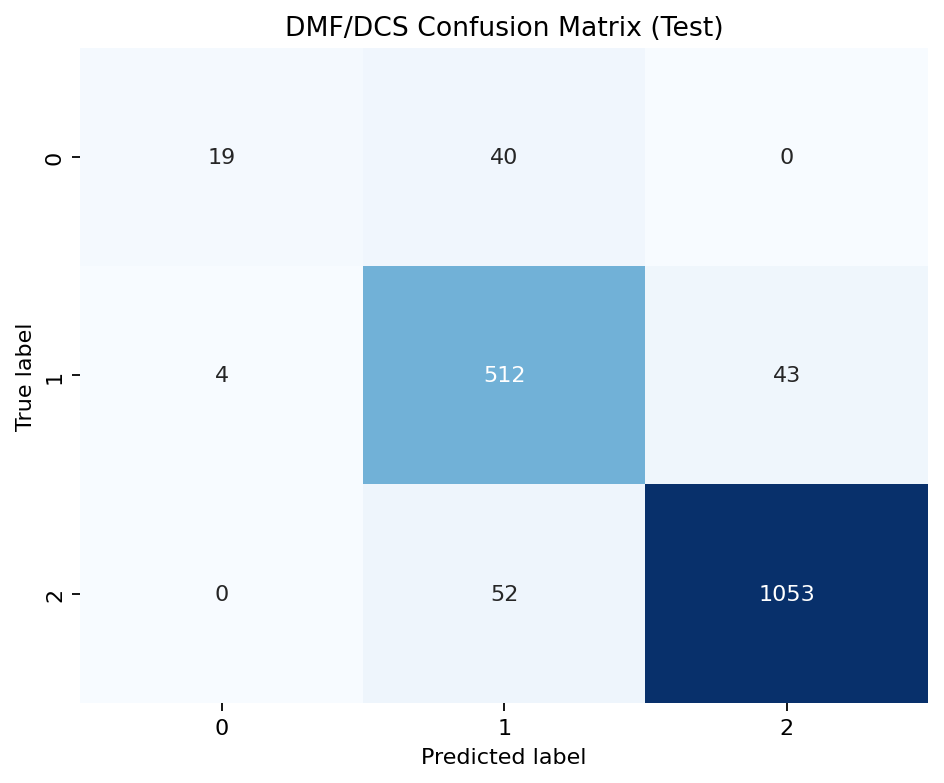

,0,1,2
0,19,40,0
1,4,512,43
2,0,52,1053


Classification report (DMF/DCS test set):
              precision    recall  f1-score   support

           0     0.8261    0.3220    0.4634        59
           1     0.8477    0.9159    0.8805       559
           2     0.9608    0.9529    0.9568      1105

    accuracy                         0.9193      1723
   macro avg     0.8782    0.7303    0.7669      1723
weighted avg     0.9195    0.9193    0.9152      1723

Saved: /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/dmf_dcs_test_confusion_matrix.png
Saved: /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/dmf_dcs_test_confusion_matrix.csv
Saved: /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/dmf_dcs_test_classification_report.csv


In [10]:
cm = confusion_matrix(y_test, dmf_pred, labels=class_ids)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(6, 5), dpi=160)
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('DMF/DCS Confusion Matrix (Test)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
cm_plot_path = DMF_ARTIFACT_DIR / 'dmf_dcs_test_confusion_matrix.png'
plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
plt.show()

display(cm_df)
print('Classification report (DMF/DCS test set):')
print(classification_report(
    y_test,
    dmf_pred,
    labels=class_ids,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

cls_report_df = pd.DataFrame(
    classification_report(
        y_test,
        dmf_pred,
        labels=class_ids,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
).transpose()
cm_csv_path = DMF_ARTIFACT_DIR / 'dmf_dcs_test_confusion_matrix.csv'
cls_csv_path = DMF_ARTIFACT_DIR / 'dmf_dcs_test_classification_report.csv'
cm_df.to_csv(cm_csv_path, encoding='utf-8-sig')
cls_report_df.to_csv(cls_csv_path, encoding='utf-8-sig')
print('Saved:', cm_plot_path)
print('Saved:', cm_csv_path)
print('Saved:', cls_csv_path)


In [11]:
# Inspect disagreement cases where DCS actually selected between LSTM and GAT.
disagreements = out[out['dcs_case'].eq('disagreement')].copy()
if len(disagreements):
    preview_cols = [
        'row_id', 'ticker', 'rating_date', 'true_label_name',
        'lstm_pred_label_name', 'gat_pred_label_name', 'dmf_pred_label_name',
        'selected_model', 'lstm_score', 'gat_score',
    ]
    display(disagreements[preview_cols].head(20))
else:
    print('Khong co case bat dong giua LSTM va GAT tren test set.')


,row_id,ticker,rating_date,true_label_name,lstm_pred_label_name,gat_pred_label_name,dmf_pred_label_name,selected_model,lstm_score,gat_score
12,test_001291,ABG,2012-08-21,1,0,1,1,gat,1.136430,1.784495
30,test_000165,ADS,2012-06-15,1,1,2,1,lstm,1.681235,1.545838
63,test_000034,AMD,2015-04-21,0,1,0,1,lstm,1.765911,0.891190
93,test_000601,APA,2015-01-16,2,2,1,2,lstm,1.866969,1.514809
95,test_001181,APA,2015-10-07,2,1,2,2,gat,1.519985,1.755115
140,test_000317,AXL,2014-01-07,1,1,2,2,gat,1.810051,1.923641
152,test_000644,BA,2012-06-15,2,2,1,2,lstm,1.903486,1.745026
159,test_000017,BAK,2014-08-08,2,2,1,2,lstm,1.573913,1.405529
188,test_000786,BKD,2015-02-20,0,0,1,1,gat,1.195998,1.518314
192,test_001116,BLDR,2013-05-13,0,0,1,1,gat,1.228277,1.713887
